# Exercise3 - Pixelwise operations

In this exercise you will learn to perform pixelwise operations using Python.

# Learning Objectives

After completing this exercise, the student should be able to do the following:

1. Convert from unsigned byte to float images using the scikit-image function `img_as_float`
2. Convert from float to unsigned byte images using the scikit-image function `img_as_ubyte`
3. Implement and test a function that can do linear histogram stretching of a grey level image.
4. Implement and test a function that can perform gamma mapping of a grey level image.
5. Implement and test a function that can threshold a grey scale image.
6. Use Otsu's automatic method to compute an optimal threshold that seperates foreground and background
7. Perform RGB thresholding in a color image.
8. Convert a RGB image to HSV using the function `rgsb2hsv` from the `skimage.color` package.
9. Visualise individual H, S, V components of a color image.
10. Implement and test thresholding in HSV space.
11. Implement and test a program that can do perform pixelwise operations on a video stream

# Installing Python packages

In this exercise, we will be using both [scikit-image](https://scikit-image.org/) and [OpenCV](https://opencv.org/). You should have both libraries installed, else instructions can be found in the previous exercises.

We will use the virtual environment from the previous exercise (`course02503`). 

# Exercise data and material

The data and material needed for this exercise can be found here:
(https://github.com/RasmusRPaulsen/DTUImageAnalysis/blob/main/exercises/ex3-PixelwiseOperations/data/)

# Explorative data analysis

First we will be working with an X-ray image of the human vertebra, `vertebra.png`. This type of images can for example be used for diagnosis of osteoporosis. A symptom is the so-called vertebral compression fracture. However, the diagnosis is very difficult to do based on x-rays alone.

**Exercise 1:** *Start by reading the image and inspect the histogram. Is it a *bimodal* histogram? Do you think it will be possible to segment it so only the bones are visible?* 

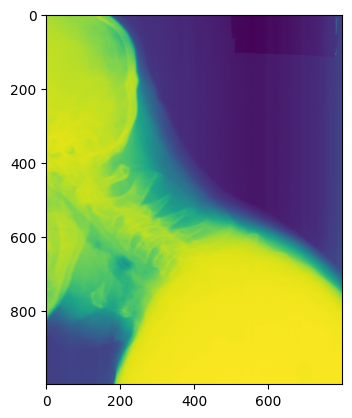

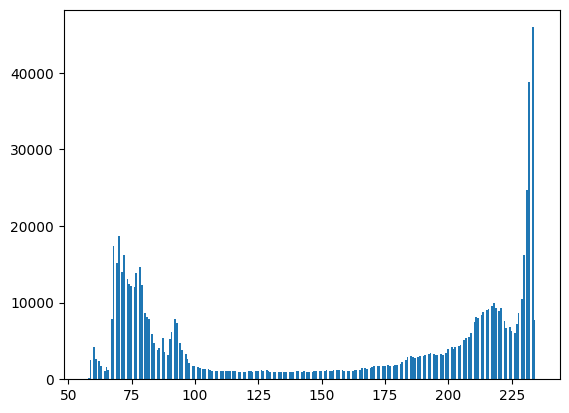

In [10]:
from skimage import color, io, img_as_ubyte, img_as_float
import matplotlib.pyplot as plt 
import numpy as np 

file = "vertebra.png"

def load_im(fname, in_dir="../data/", float: bool = False):
    img = io.imread(in_dir+fname)
    if float: 
        return img_as_float(img)
    return img 

img = load_im(file)
plt.imshow(img)

plt.figure()
h = plt.hist(img.ravel(),bins=256)

Looks fairly possible. There is some connective tissue in in the high-end which may make it hard though. On the other hand, there is a very strong peak which definitely must be bone, the question is just how much of the bone we get. Vertebrae will be hard, as they usually have darker inner regions


**Exercise 2:** *Compute the minimum and maximum values of the image. Is the full scale of the gray-scale spectrum used or can we enhance the appearance of the image?*


In [ ]:
v_min, v_max = img.min(), img.max()
print(v_min,v_max)

#we can enhance 

57 235



# Pixel type conversions

Before going further, we need to understand how to convert between between pixel types and what should be considered. A comphrehensive guide can be found [here](https://scikit-image.org/docs/stable/user_guide/data_types.html) (it is not mandatory reading, we just use some highlights). One important point is that we should avoid using the `astype` function on images. 

## Conversion from unsigned byte to float image

In *unsigned byte* images, the possible pixel value range is [0, 255]. When converting an *unsigned byte* image to a *float* image, the possible pixel value range will be [0, 1]. When you use Python skimage function `img_as_float` on an *unsigned byte* image, it will automatically divide all pixel values with 255.

**Exercise 3:** *Add an import statement to your script:*
```
from skimage.util import img_as_float
from skimage.util import img_as_ubyte
```

*Read the image `vertebra.png` and compute and show the minumum and maximum values.*

*Use `img_as_float` to compute a new float version of your input image. Compute the minimum and maximum values of this float image. Can you verify that the float image is equal to the original image, where each pixel value is divided by 255?*

In [12]:
img_float = img_as_float(img)
v_min, v_max = img_float.min(), img_float.max()
print(v_min,v_max)


0.22352941176470587 0.9215686274509803


## Conversion from float image to unsigned byte image

As stated above, an (unsigned) float image can have pixel values in [0, 1]. When using the Python skimage function `img_as_ubyte` on an (unsigned) float image, it will multiply all values with 255 before converting into a byte. Remember that all decimal number will be converted into integers by this, and some information might be lost.

**Exercise 4:** *Use `img_as_ubyte` on the float image you computed in the previous exercise. Compute the Compute the minimum and maximum values of this image. Are they as expected?*

In [ ]:
img_recast = img_as_ubyte(img_float)

print(np.linalg.norm(img_recast-img,ord=np.inf)) #absolutely the same image in this case

0.0


# Histogram stretching

You should implement a function, that automatically stretches the histogram of an image. In other words, the function should create a new image, where the pixel values are changed so the histogram of the output image is *optimal*. Here *optimal* means, that the minimum value is 0 and the maximum value is 255. It should be based on the *linear histogram stretching* equation:

$$g(x,y) =\frac{v_\text{max,d}-v_\text{min,d}}{v_\text{max}-v_\text{min}}(f(x,y) - v_\text{min} )+v_\text{min,d} \enspace .$$

Here $f(x,y)$ is the input pixel value and  $g(x,y)$ is the output pixel value, $v_\text{max,d}$ and $v_\text{min,d}$ are the desired minimum and maximum values (0 and 255) and  $v_\text{max}$ and $v_\text{min}$ are the current minumum and maximum values.

**Exercise 5:** *Implement a Python function called `histogram_stretch`. It can, for example, follow this example:*

In [14]:
def histogram_stretch(img_in):
    """
    Stretches the histogram of an image 
    :param img_in: Input image
    :return: Image, where the histogram is stretched so the min values is 0 and the maximum value 255
    """
    # img_as_float will divide all pixel values with 255.0
    img_float = img_as_float(img_in)
    min_val = img_float.min()
    max_val = img_float.max()
    min_desired = 0.0
    max_desired = 1.0
	
    # Do something here
    img_float = ((max_desired-min_desired)/(max_val-min_val))*(img_float-min_val)+min_desired

    # img_as_ubyte will multiply all pixel values with 255.0 before converting to unsigned byte
    return img_as_ubyte(img_float)


**Exercise 6:** *Test your `histogram_stretch` on the `vertebra.png` image. Show the image before and after the histogram stretching. What changes do you notice in the image? Are the important structures more visible?*

221 211


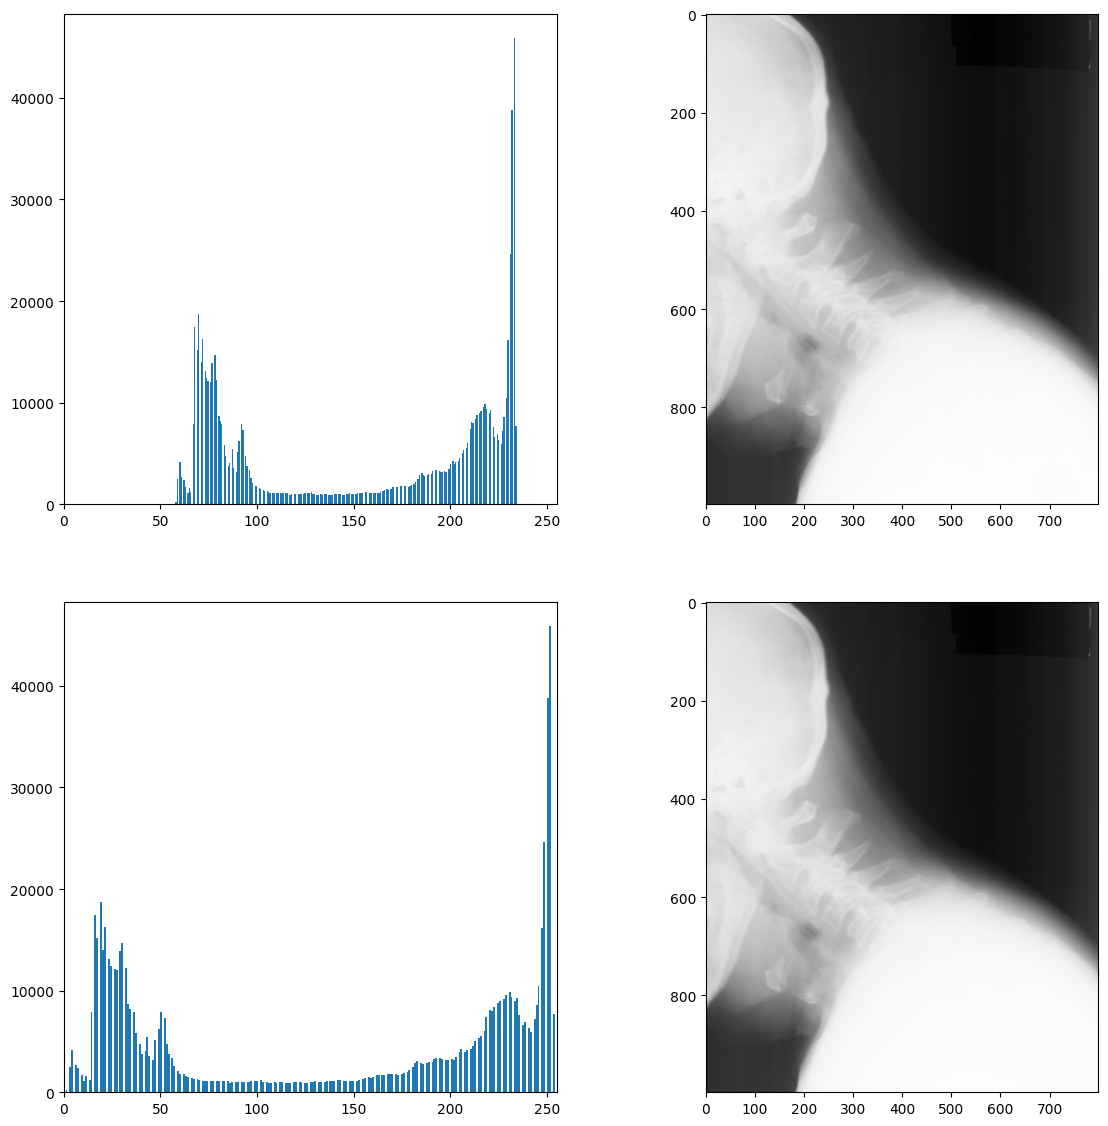

In [22]:
img_stretch = histogram_stretch(img)
fig, ax = plt.subplots(2,2,figsize=(14,14))
ax[0,0].hist(img.ravel(),bins=256)
ax[1,0].hist(img_stretch.ravel(),bins=256)
ax[0,1].imshow(img,cmap="gray")
ax[1,1].imshow(img_stretch,cmap="gray")
ax[0,0].set_xlim([0,255])
ax[1,0].set_xlim([0,255])

print(img_stretch[10,10],img[10,10])


# Non-linear pixel value mapping

The goal is to implement and test a function that performs a $\gamma$-mapping of pixel values:

$$g(x,y) = f(x,y)^\gamma \enspace .$$

You can use the *Numpy* function `power` to compute the actual mapping function. 

**Exercise 7:** *Implement a function, `gamma_map(img, gamma)`, that:*

1. Converts the input image to float
2. Do the gamma mapping on the pixel values
3. Returns the resulting image as an unsigned byte image.



In [23]:
def gamma_map(img: np.ndarray, gamma: float) -> np.ndarray:
    """
    Gamma-mapping of an image. Image is converted to float and reconverted to byte uint8

    Args:
        img (np.ndarray): image array in form [H,W] or [H,W,1]
        gamma (float): the gamma value

    Returns:
        np.ndarray: converted uint8 byte array
    
    """
    img = img_as_float(img)
    img = np.power(img,gamma)
    return img_as_ubyte(img)



**Exercise 8:** *Test your `gamma_map` function on the vertebra image or another image of your choice. Try different values of* $\gamma$, *for example 0.5 and 2.0. Show the resuling image together with the input image. Can you see the differences in the images?*


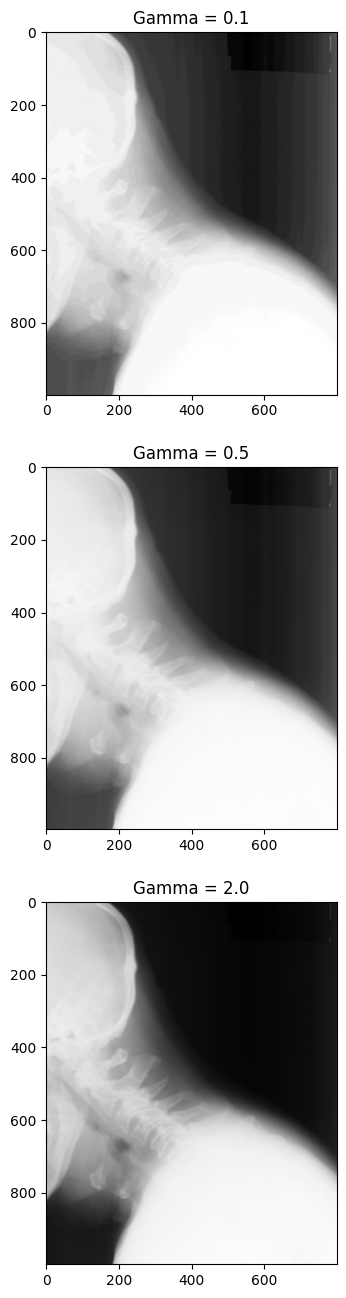

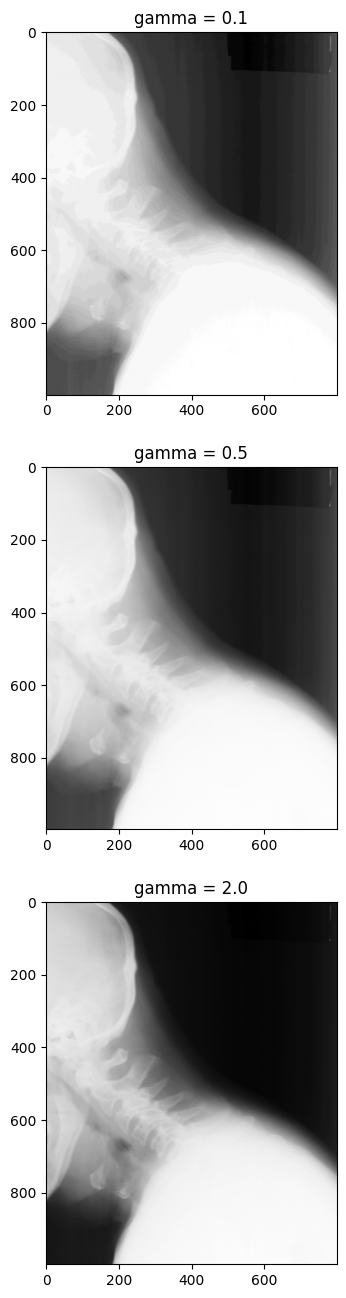

In [ ]:
gammas = [0.1,0.5,2.0]
plot_dim = 16
fig, ax = plt.subplots(len(gammas),1,figsize=(len(gammas)*plot_dim,plot_dim))

for i, g in enumerate(gammas):
    img_gam = gamma_map(img=img,gamma=g)
    ax[i].imshow(img_gam, cmap="gray")
    ax[i].set_title(f"Gamma = {g}")

def image_column(fun, img: np.ndarray, fun_args: list = None, title: str = None) -> None:
    plot_dim = 16
    fig, ax = plt.subplots(len(fun_args),1,figsize=(len(fun_args)*plot_dim,plot_dim))
    for i, arg in enumerate(fun_args):
        img_trf = fun(img,arg)
        ax[i].imshow(img_trf, cmap="gray")
        ax[i].set_title(f"{title} = {arg}")




So low gamma gives us more "dark-levels", whereas high gamma gives us more "light"-levels, or in other words, the black-resolution is higher for low gammma and reverse for large gamma. Makes sense, considering formula


# Image segmentation by thresholding

Now we will try to implement some functions that can seperate an image into *segments*. In this exercise, we aim at seperating the *background* from the *foreground* by setting a threshold in a gray scale image or several thresholds in color images.

**Exercise 9:** *Implement a function, `threshold_image` :*

In [ ]:

#how one could implement typing for such stuff 
# from typing import TypeVar, Union
# from numpy.typing import NDArray
# import numpy as np

# Numeric = Union[np.generic, float, int]
# T = TypeVar("T", bound=Numeric)

# # def threshold_image(img_in: NDArray, thres: T) -> NDArray[np.uint8]:
# #     if not np.issubdtype(type(thres), img_in.dtype.type):
# #         # fallback check for plain Python scalars
# #         if not np.issubdtype(np.array(thres).dtype, img_in.dtype):
# #             raise TypeError(f"Threshold type {type(thres)} does not match image dtype {img_in.dtype}")

# #     mask = img_in > thres
# #     img_in[mask] = 1


numpy.uint8

In [64]:
def threshold_image(img_in, thres: int):
    """
    Apply a threshold in an image and return the resulting image
    :param img_in: Input image
    :param thres: The treshold value in the range [0, 255]
    :return: Resulting image (unsigned byte) where background is 0 and foreground is 255
    """
    img_in = img_as_ubyte(img_in)
    if isinstance(thres,float):
        thres = int(thres*255)
        print(f"Received float threshold, converted to nearest int: {thres}")
    mask = img_in>thres
    img_out = img_in.copy()
    img_out[mask] = 255
    img_out[~mask] = 0
    return img_as_ubyte(img_out) 



Remember to use `img_as_ubyte` when returning the resulting image. 

**Exercise 10:** *Test your `threshold_image` function on the vertebra image with different thresholds. It is probably not possible to find a threshold that seperates the bones from the background, but can you find a threshold that seperates the human from the background?*



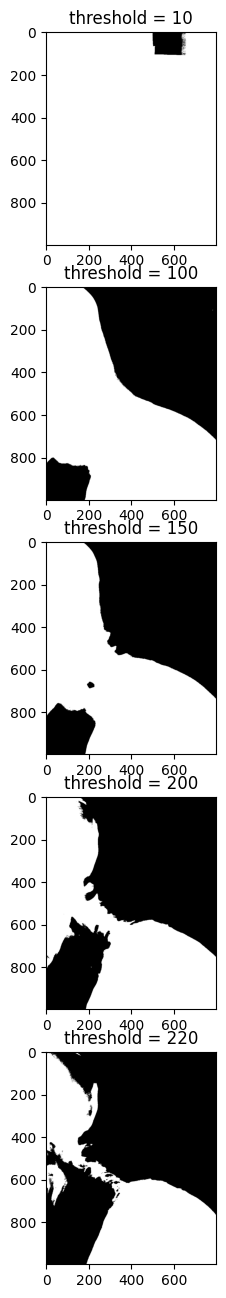

In [52]:
image_column(threshold_image,img_stretch,fun_args=[10,100,150,200,220],title="threshold")


## Automatic thresholds using Otsu's method

An optimal threshold can be estimated using [*Otsu's method*](https://en.wikipedia.org/wiki/Otsu%27s_method). This method finds the threshold, that minimizes the combined variance of the foreground and background.

**Exercise 11:** *Read the documentation of [Otsu's method](https://scikit-image.org/docs/dev/api/skimage.filters.html#skimage.filters.threshold_otsu) and use it to compute and apply a threshold to the vertebra image.*

Remember to import the method:
```
from skimage.filters import threshold_otsu
```

*How does the threshold and the result compare to your manually found threshold?*



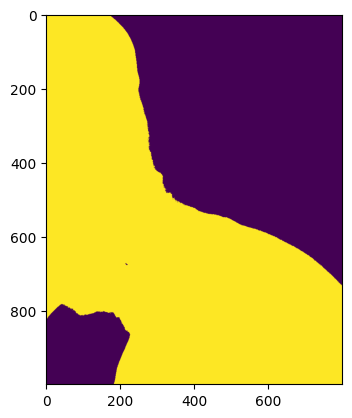

In [49]:
from skimage.filters import threshold_otsu 

thresh = threshold_otsu(img_stretch)

otsu_im = threshold_image(img_stretch,thresh)
plt.imshow(otsu_im)

**Exercicse 12:** *Use your camera to take some pictures of yourself or a friend. Try to
take a picture on a dark background. Convert the image to grayscale
and try to find a threshold that creates a **silhouette** image (an image where the head is all white and the background black).*

Alternatively, you can use the supplied photo **dark_background.png** found in the [exercise data](https://github.com/RasmusRPaulsen/DTUImageAnalysis/blob/main/exercises/ex3-PixelwiseOperations/data/).

[[0.01007529 0.01007529 0.01007529 ... 0.01007529 0.01007529 0.        ]
 [0.01007529 0.01007529 0.01007529 ... 0.01007529 0.01007529 0.01007529]
 [0.01007529 0.01007529 0.01007529 ... 0.01007529 0.01007529 0.01007529]
 ...
 [0.01007529 0.01007529 0.01007529 ... 0.01007529 0.01007529 0.01007529]
 [0.01007529 0.01007529 0.01007529 ... 0.01007529 0.01007529 0.01007529]
 [0.01007529 0.01007529 0.01007529 ... 0.01007529 0.01007529 0.01007529]]


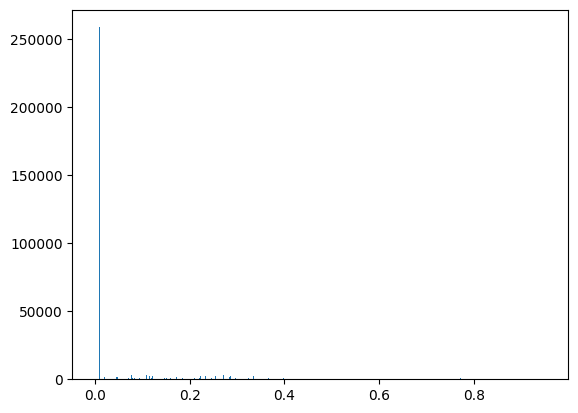

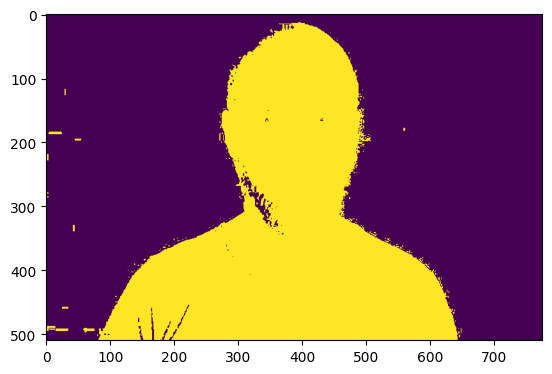

In [75]:
img = load_im("dark_background.png")
img = color.rgb2gray(img)
print(img)
plt.figure()
h = plt.hist(img.ravel(),bins=800)
max_bin = h[0].argmax()
bin_edge = (h[1][max_bin],h[1][max_bin+1])

mask = img>bin_edge[-1]

plt.figure()
plt.imshow(mask)

## Color thresholding in the RGB color space

In the following, we will make a simple system for road-sign detection. Start by reading the image **DTUSigns2.jpg** found in the [exercise data](https://github.com/RasmusRPaulsen/DTUImageAnalysis/blob/main/exercises/ex3-PixelwiseOperations/data/). We want to make a system that do a *segmentation* of the image - meaning that a new binary image is created, where the foreground pixels correspond to the sign we want to detect.

We do that by tresholding the colour-channels individually. This code segments out the blue sign:

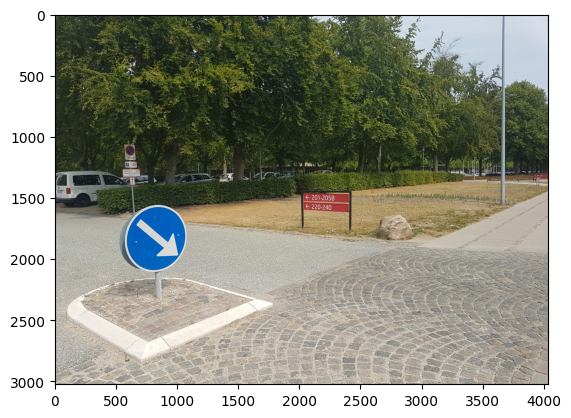

In [78]:
im_org = load_im("DTUSigns2.jpg")
plt.imshow(im_org)

r_comp = im_org[:, :, 0]
g_comp = im_org[:, :, 1]
b_comp = im_org[:, :, 2]
segm_blue = (r_comp < 10) & (g_comp > 85) & (g_comp < 105) & \
            (b_comp > 180) & (b_comp < 200)




**Exercise 13:** *Create a function `detect_dtu_signs` that takes as input a color image and returns an image, where the blue sign is identified by foreground pixels.*

/tmp/ipykernel_17074/3024968429.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap)


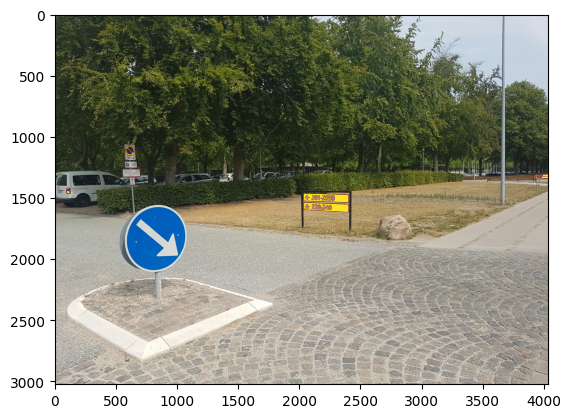

In [106]:
def detect_dtu_signs(im: np.ndarray, color: str) -> np.ndarray:
    r_comp = im[:, :, 0]
    g_comp = im[:, :, 1]
    b_comp = im[:, :, 2]
    
    if color.lower()=="b":
        mask = (r_comp < 10) & (g_comp > 85) & (g_comp < 105) & \
            (b_comp > 180) & (b_comp < 200)
    
    if color.lower()=="r":
        mask = (r_comp > 100) & (g_comp > 25) & (g_comp < 70) & \
            (b_comp > 15) & (b_comp < 70)
    

    return mask 
 
import matplotlib.cm as cm 
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

def cmap_alpha(cmap="viridis_r"):
    """
    Makes a colormap where 0 is transparent, nice for segmentations overlaid over images 
    """
    cmap = cm.get_cmap(cmap)
    colors = cmap(np.arange(cmap.N))
    colors[: int(cmap.N / 2), 3] = np.linspace(0, 1, int(cmap.N / 2))  # Modify alpha channel
    colors[int(cmap.N / 2) :, 3] = 1  # Modify alpha channel
    cmap = ListedColormap(colors)
    return cmap

def show_seg_with_alpha(im,mask, cmap, alpha):
    alpha_cmap = cmap_alpha(cmap)
    plt.figure()
    plt.imshow(im)
    plt.imshow(mask,cmap=alpha_cmap,alpha=alpha)

mask = detect_dtu_signs(im_org,"r")


show_seg_with_alpha(im_org,mask,"viridis", alpha=0.99)

**Exercise 14:** *Extend your `detect_dtu_signs` function so it can also detect red signs. You can add an argument to the function, that tells which color it should look for. 
You should use one of the explorative image tools to find out what the typical RGB values are in the red signs.*

## Color thresholding in the HSV color space

Sometimes it gives better segmentation results when the tresholding is done in HSI (also known as HSV - hue, saturation, value) space. Start by reading the  **DTUSigns2.jpg** image, convert it to HSV and show the hue and value (from [here](https://scikit-image.org/docs/stable/auto_examples/color_exposure/plot_rgb_to_hsv.html)):

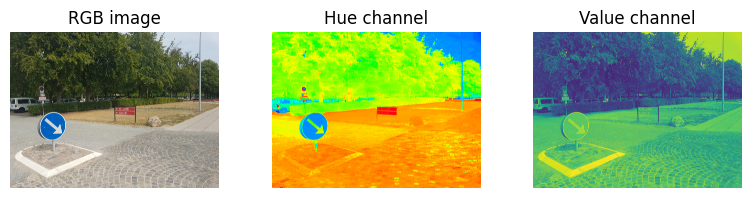

In [ ]:
im_org = load_im("DTUSigns2.jpg")

hsv_img = color.rgb2hsv(im_org)
hue_img = hsv_img[:, :, 0]
value_img = hsv_img[:, :, 2]
fig, (ax0, ax1, ax2) = plt.subplots(ncols=3, figsize=(8, 2))
ax0.imshow(im_org)
ax0.set_title("RGB image")
ax0.axis('off')
ax1.imshow(hue_img, cmap='hsv')
ax1.set_title("Hue channel")
ax1.axis('off')
ax2.imshow(value_img)
ax2.set_title("Value channel")
ax2.axis('off')

fig.tight_layout()
#fig.savefig("im_for_thresh.png")
plt.show()

###this can only be solved using inspection with python, we need the intensities of the images -> use inspection script 


**Exercise 15:** *Now make a sign segmentation function using tresholding in HSV space and locate both the blue and the red sign.*

/tmp/ipykernel_17074/3024968429.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap)


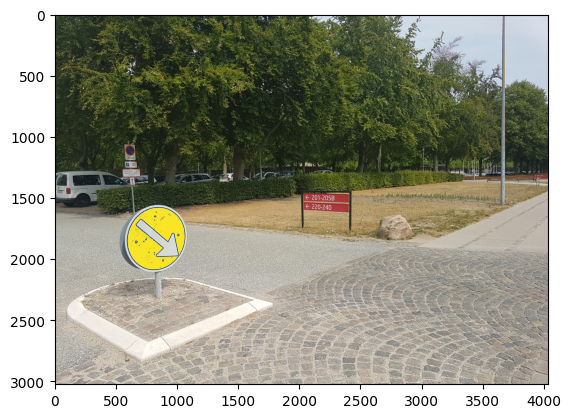

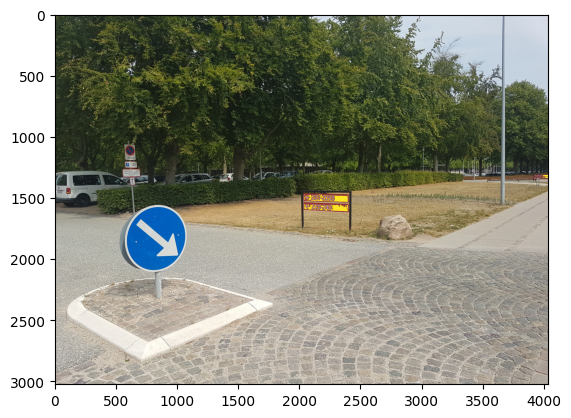

In [109]:
def detect_dtu_signs_hsv(im: np.ndarray, color: str) -> np.ndarray:
    
    h_comp = im[:, :, 0]
    s_comp = im[:, :, 1]
    v_comp = im[:, :, 2]
    
    if color.lower()=="b":
        mask = (h_comp > 0.550) & (h_comp < 0.80) & (v_comp >= 0.70) & (v_comp<0.8) 
    
    if color.lower()=="r":
        mask = (h_comp > 0.90) & (v_comp>=0.478) & (v_comp < 0.70) 
    
    #other sign is v 0.427 h 0.996

    return mask 



mask_blue = detect_dtu_signs_hsv(hsv_img,color="b")
show_seg_with_alpha(im_org,mask_blue,"viridis", alpha=0.99)

mask_red = detect_dtu_signs_hsv(hsv_img,color="r")
show_seg_with_alpha(im_org,mask_red,"viridis", alpha=0.99)

# Real time pixelwise operations on videos

In the [exercise material](https://github.com/RasmusRPaulsen/DTUImageAnalysis/blob/main/exercises/ex3-PixelwiseOperations/data/), there is a Python script using OpenCV that:

1. Connects to a camera
2. Acquire images, converts them to gray-scale
3. Do a simple processing on the gray-scale (inversion) or the colour image (inversion of the red channel)
4. Computes the frames per second (fps) and shows it on an image.
5. Shows input and resulting images in windows.
6. Checks if the key `q` has been pressed and stops the program if it is pressed.

It is possible to use a mobile phone as a remote camera by following the instructions in exercise 2b.

**Exercise 16:** *Run the program from the [exercise material](https://github.com/RasmusRPaulsen/DTUImageAnalysis/blob/main/exercises/ex3-PixelwiseOperations/data/) and see if it shows the expected results? *

**Exercise 17:** *Change the gray-scale processing in the [exercise material](https://github.com/RasmusRPaulsen/DTUImageAnalysis/blob/main/exercises/ex3-PixelwiseOperations/data/) script to be for example thresholding, gamma mapping or something else. Do you get the visual result that you expected?*

**Exercise 18:** *Real time detection of DTU signs*

Change the rgb-scale processing in the [exercise material](https://github.com/RasmusRPaulsen/DTUImageAnalysis/blob/main/exercises/ex3-PixelwiseOperations/data/) script so it does a color threshold in either RGB or HSV space. The goal is to make a program that can *see* DTU street signs. The output should be a binary image, where the pixels of the sign is foreground. Later in the course, we will learn how to remove the noise pixels.